# Phase 09.1 ABL-03 Analysis — 3-pipeline preprocessing ablation, 5 seeds, OD-scale fidelity

This notebook is the **capstone analysis** for the R1-M3 preprocessing ablation (CONTEXT.md decisions D-09.1-12 through D-09.1-19). It loads every (pipeline, seed) artifact from `revision/results/transform_ablation/runs/`, inverts the synthetic samples back to OD scale per pipeline, builds the long-form `metrics.csv` (D-09.1-14), renders six publication-grade figures (D-09.1-13), trains a per-pipeline TSTR-lite LSTM (D-09.1-10, CD-4), and writes the rebuttal `summary.md` answering the four named R1-M3 questions (D-09.1-15).

**Key data interpretation note:** `samples.npy` from the CLI driver is the generator output after `* 0.1` scaling (`revision/run_ablation.py:205`). Training compares the critic `real_batch_tensor` (in `[-1, 1]`) against `generator(noise) * 0.1` (in `[-0.1, 0.1]`). To reproduce v1.1 parity behavior on inversion, we **multiply samples by 10** before applying the inverse transforms (which expect the `[-1, 1]` standardized window space).

Per D-09.1-19: all plotting and aggregation logic lives in this notebook; no new helpers are added to `revision/core/`.

All randomness uses `np.random.default_rng(seed)` (D-09.1-18). Notebook is reproducible top-to-bottom.

In [1]:
import json, os, sys, yaml
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Repo-root finder (copied verbatim from revision/02_eval06_roundtrip.ipynb cell 2).
def _find_repo_root():
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / 'data.csv').exists() and (d / 'revision' / 'core').is_dir():
            return d
    raise FileNotFoundError('Could not locate repo root from ' + str(here))

REPO_ROOT = _find_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from revision.core.preprocessing import (
    forward_minmax_od, inverse_minmax_od,
    forward_logreturns, inverse_logreturns,
    forward_lambert, inverse_lambert,
)
from revision.core.data import load_and_preprocess, full_denorm_pipeline, rolling_window
from revision.core.eval import compute_emd, compute_acf, compute_dtw, compute_moments
from revision.core import WINDOW_LENGTH

sns.set_style('whitegrid')
print(f'REPO_ROOT = {REPO_ROOT}')
print(f'WINDOW_LENGTH = {WINDOW_LENGTH}')


REPO_ROOT = /Users/shawngibford/dev/phd/qGAN
WINDOW_LENGTH = 10


/opt/homebrew/lib/python3.11/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


In [2]:
# Load real OD reference data (single campaign, 778 OD points).
d_real = load_and_preprocess('./data.csv')
real_OD = d_real['OD'].cpu().numpy().astype(np.float64)              # (778,)
real_log_delta = d_real['log_delta'].cpu().numpy().astype(np.float64) # (777,)
real_windowed_OD = rolling_window(d_real['OD'], WINDOW_LENGTH, 2).cpu().numpy().astype(np.float64)  # (385, 10)
real_od_starts = real_windowed_OD[:, 0]                              # (385,)

# real log-returns windowed (length-10) for Pipeline B/C transformed-space ACF.
# (log-returns are length 777 = OD_length - 1; windows of length 10 with stride 2 -> 384 windows.)
real_windowed_lr = rolling_window(d_real['log_delta'], WINDOW_LENGTH, 2).cpu().numpy().astype(np.float64)  # (384, 10)

print(f'real OD: {real_OD.shape}, range=[{real_OD.min():.3f}, {real_OD.max():.3f}]')
print(f'real_windowed_OD: {real_windowed_OD.shape}')
print(f'real_log_delta: {real_log_delta.shape}, std={real_log_delta.std():.4f}')
print(f'real_windowed_lr: {real_windowed_lr.shape}')


real OD: (778,), range=[0.470, 3.800]
real_windowed_OD: (385, 10)
real_log_delta: (777,), std=0.0217
real_windowed_lr: (384, 10)


In [3]:
PIPELINES = ['A', 'B', 'C']
SEEDS = [42, 43, 44, 45, 46]
OUT_ROOT = Path('revision/results/transform_ablation')

def reconstruct_od(pipeline: str, seed: int, n_synth_subsample: int | None = None) -> dict:
    """Load samples_pm1 from disk, multiply by 10 to undo the 0.1 generator-output scaling,
    then invert per pipeline. Returns dict with OD-scale samples and transformed-space samples.

    The saved samples.npy is `generator(noise) * 0.1` per run_ablation.py:205, but the inverse
    transforms expect the [-1, 1] training-window space, so we multiply by 10 first.
    """
    base = OUT_ROOT / 'runs' / pipeline / str(seed)
    samples_raw = np.load(base / 'samples.npy').astype(np.float64)  # in [-0.1, 0.1]
    samples_pm1 = samples_raw * 10.0                                  # back to [-1, 1] scale
    inv = np.load(base / 'inverse_kwargs.npz', allow_pickle=True)

    if n_synth_subsample is not None and samples_pm1.shape[0] > n_synth_subsample:
        rng = np.random.default_rng(seed)
        idx = rng.choice(samples_pm1.shape[0], n_synth_subsample, replace=False)
        samples_pm1 = samples_pm1[idx]

    if pipeline == 'A':
        od_min = float(inv['od_min']); od_max = float(inv['od_max'])
        # Pipeline A: [-1,1] -> [0,1] -> OD
        od01 = (samples_pm1 + 1.0) / 2.0
        od = od01 * (od_max - od_min) + od_min
        return {'od_samples': od, 'transformed': None,
                'n_synth': od.shape[0], 'pipeline': pipeline, 'seed': seed}

    if pipeline == 'B':
        r_min = float(inv['r_min']); r_max = float(inv['r_max'])
        mu = float(inv['mu']); sigma = float(inv['sigma'])
        od_starts_pool = np.asarray(inv['od_starts']).astype(np.float64)
        # Un-rescale [-1, 1] -> standardized log-returns.
        r_norm = ((samples_pm1 + 1.0) / 2.0) * (r_max - r_min) + r_min  # (N, 10) standardized log-returns
        # Sample real OD0 per window WITH REPLACEMENT (CD-5).
        rng = np.random.default_rng(seed * 7919 + 1)
        od_start_per_window = rng.choice(od_starts_pool, size=r_norm.shape[0], replace=True)
        r_norm_t = torch.tensor(r_norm)
        od_start_t = torch.tensor(od_start_per_window)
        od_full = inverse_logreturns(r_norm_t, od_start_t,
                                     torch.tensor(mu), torch.tensor(sigma)).cpu().numpy()
        # inverse_logreturns returns length L+1 when input is length L (prepends OD_0).
        # We want length-10 OD windows, so truncate to first 10.
        if od_full.shape[1] > 10:
            od = od_full[:, :10]
        else:
            od = od_full
        return {'od_samples': od, 'transformed': r_norm,
                'n_synth': od.shape[0], 'pipeline': pipeline, 'seed': seed}

    if pipeline == 'C':
        trans_norm = torch.tensor(np.asarray(inv['transformed_norm_log_delta']),
                                   dtype=torch.float64)
        mu = float(inv['mu']); sigma = float(inv['sigma']); delta_const = float(inv['delta'])
        # full_denorm_pipeline: gen_windows in [-1, 1] -> log-returns (un-Lambert + un-standardize)
        pipe_out = full_denorm_pipeline(
            torch.tensor(samples_pm1).double(),
            trans_norm,
            torch.tensor(mu, dtype=torch.float64),
            torch.tensor(sigma, dtype=torch.float64),
            delta_const,
        ).cpu().numpy()
        # pipe_out is flat (N*10,) log-returns. Reshape to (N, 10).
        log_returns_windowed = pipe_out.reshape(samples_pm1.shape[0], samples_pm1.shape[1])
        # Cumulative-integrate from real OD0 (same recipe as Pipeline B for fair OD-scale comparison).
        rng = np.random.default_rng(seed * 7919 + 2)
        od_start_per_window = rng.choice(real_od_starts, size=log_returns_windowed.shape[0], replace=True)
        cum = np.cumsum(log_returns_windowed, axis=1)                       # (N, 10)
        # Construct length-10 OD: OD[0] = od_start, OD[1..9] = od_start * exp(cum[0..8])
        cum_full = np.concatenate([np.zeros((cum.shape[0], 1)), cum[:, :-1]], axis=1)  # (N, 10)
        log_od = np.log(od_start_per_window)[:, None] + cum_full              # (N, 10)
        od = np.exp(log_od)
        return {'od_samples': od, 'transformed': log_returns_windowed,
                'n_synth': od.shape[0], 'pipeline': pipeline, 'seed': seed}

    raise ValueError(f'unknown pipeline {pipeline}')

# Sanity probe: reconstruct A/42 and B/42 and C/42 and report OD ranges.
for p in PIPELINES:
    r = reconstruct_od(p, 42)
    od = r['od_samples']
    print(f'{p}/42: od shape={od.shape}, range=[{od.min():.3f}, {od.max():.3f}], '
          f'mean={od.mean():.3f}, std={od.std():.3f}')


A/42: od shape=(3850, 10), range=[1.075, 3.142], mean=2.133, std=0.287
B/42: od shape=(3840, 10), range=[0.433, 4.515], mean=1.407, std=0.886
C/42: od shape=(3840, 10), range=[0.455, 4.178], mean=1.399, std=0.858


In [4]:
# Build metrics.csv (D-09.1-14 long-form schema): pipeline,seed,metric_name,scale,value.
rows = []
NLAGS = 9  # window-length-10 -> lags 0..9
DTW_N_PAIRS = 200  # nearest-neighbor DTW on a subset to control runtime (T-09.1.04-05 accept).

real_flat = real_windowed_OD.reshape(-1)

for p in PIPELINES:
    for s in SEEDS:
        r = reconstruct_od(p, s)
        od = r['od_samples']            # (N, 10) OD scale
        synth_flat = od.reshape(-1)
        # ── OD-scale per-window pooled marginal EMD + moments ─────────────
        rows.append(dict(pipeline=p, seed=s, metric_name='emd', scale='OD',
                         value=compute_emd(real_flat, synth_flat)))
        for k, v in compute_moments(synth_flat).items():
            rows.append(dict(pipeline=p, seed=s, metric_name=f'moment_{k}',
                             scale='OD', value=v))
        # ── OD-scale per-window ACF, aggregate mean + std across windows ──
        acfs = np.stack([compute_acf(w, nlags=NLAGS) for w in od])  # (N, NLAGS+1)
        for lag in range(NLAGS + 1):
            rows.append(dict(pipeline=p, seed=s, metric_name=f'acf_lag{lag}_mean',
                             scale='OD', value=float(acfs[:, lag].mean())))
            rows.append(dict(pipeline=p, seed=s, metric_name=f'acf_lag{lag}_std',
                             scale='OD', value=float(acfs[:, lag].std())))
        # ── DTW distribution (nearest-neighbor, subsample for runtime) ─────
        rng_dtw = np.random.default_rng(s * 31)
        n_synth_for_dtw = min(DTW_N_PAIRS, od.shape[0])
        synth_idx = rng_dtw.choice(od.shape[0], size=n_synth_for_dtw, replace=False)
        dtw_vals = []
        for i in synth_idx:
            best = min(compute_dtw(od[i], real_windowed_OD[j])
                       for j in range(real_windowed_OD.shape[0]))
            dtw_vals.append(best)
        rows.append(dict(pipeline=p, seed=s, metric_name='dtw_mean',
                         scale='OD', value=float(np.mean(dtw_vals))))
        rows.append(dict(pipeline=p, seed=s, metric_name='dtw_median',
                         scale='OD', value=float(np.median(dtw_vals))))
        rows.append(dict(pipeline=p, seed=s, metric_name='dtw_std',
                         scale='OD', value=float(np.std(dtw_vals))))
        # ── Transformed-space EMD (B and C only; A has no separate space). ──
        if r['transformed'] is not None:
            trans_flat = r['transformed'].reshape(-1)
            real_trans = real_log_delta  # both B and C compare against log-returns space
            rows.append(dict(pipeline=p, seed=s, metric_name='emd',
                             scale='transformed', value=compute_emd(real_trans, trans_flat)))
        print(f'  done {p}/{s}: emd_OD={rows[-2 if r["transformed"] is not None else -1]["value"] if False else compute_emd(real_flat, synth_flat):.4f}')

# Pipeline C log-return EMD vs v1.1 baseline (D-09.1-12) — record as a meta row.
parity = json.loads(Path('revision/results/parity_check.json').read_text())
baseline_emd = float(parity['post']['emd'])
rows.append(dict(pipeline='meta', seed=-1, metric_name='v1_1_baseline_emd',
                 scale='transformed', value=baseline_emd))

df = pd.DataFrame(rows, columns=['pipeline', 'seed', 'metric_name', 'scale', 'value'])
df.to_csv(OUT_ROOT / 'metrics.csv', index=False)
print(f'\nmetrics.csv written: {len(df)} rows')
print(df[df.metric_name == 'emd'])


  done A/42: emd_OD=0.9000


  done A/43: emd_OD=0.8947


  done A/44: emd_OD=0.8833


  done A/45: emd_OD=0.8994


  done A/46: emd_OD=0.9034


...

  done C/42: emd_OD=0.0266


  done C/43: emd_OD=0.0295


  done C/44: emd_OD=0.0375


  done C/45: emd_OD=0.0182


  done C/46: emd_OD=0.0199

metrics.csv written: 431 rows
    pipeline  seed metric_name        scale     value
0          A    42         emd           OD  0.899997
28         A    43         emd           OD  0.894725
56         A    44         emd           OD  0.883334
84         A    45         emd           OD  0.899396
112        A    46         emd           OD  0.903436
140        B    42         emd           OD  0.022748
168        B    42         emd  transformed  0.568444
169        B    43         emd           OD  0.034635
197        B    43         emd  transformed  0.592884
198        B    44         emd           OD  0.032598
226        B    44         emd  transformed  0.640029
227        B    45         emd           OD  0.026006
255        B    45         emd  transformed  0.587522
256        B    46         emd           OD  0.024133
284        B    46         emd  transformed  0.576601
285        C    42         emd           OD  0.026613
313        C    42      

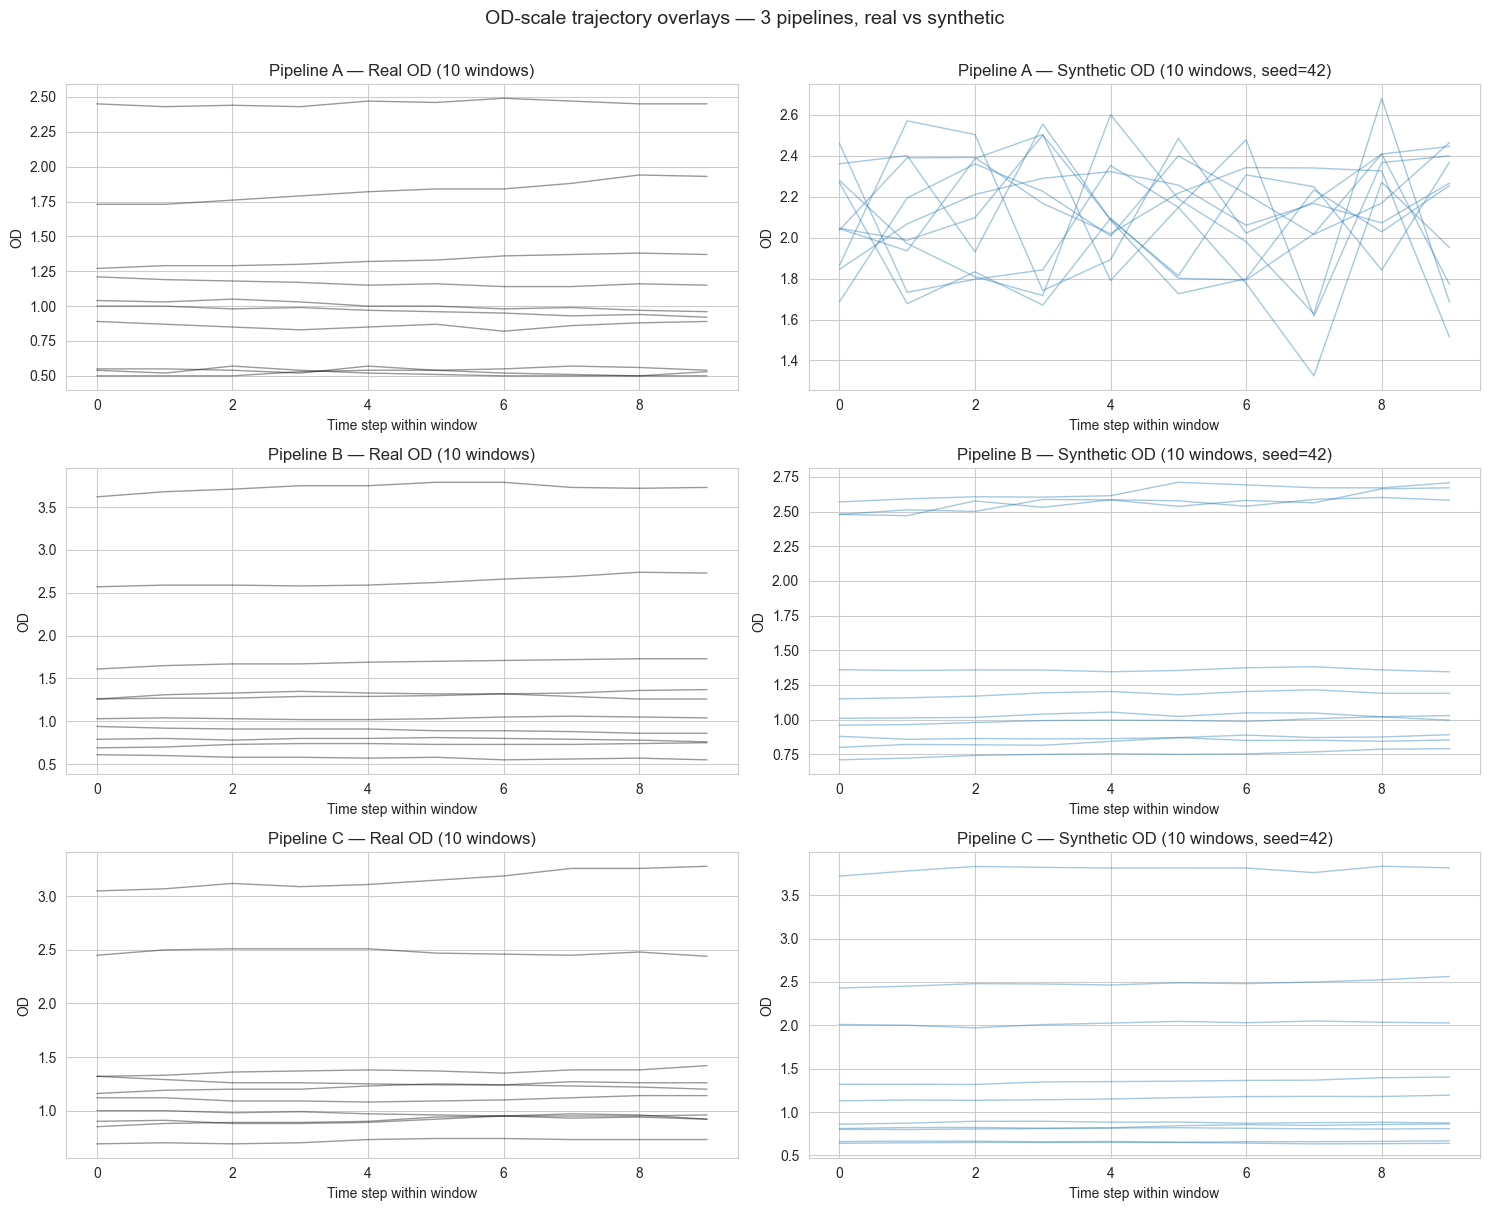

wrote revision/results/transform_ablation/figures/fig_trajectories.png


In [5]:
# fig_trajectories.png — 3 rows (pipelines) x 2 cols (real, synthetic), 10 trajectories per panel.
FIG_DIR = OUT_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
rng_traj = np.random.default_rng(42)
for i, p in enumerate(PIPELINES):
    r = reconstruct_od(p, 42)
    od = r['od_samples']
    # Real panel (col 0): 10 random real windows.
    real_idx = rng_traj.choice(real_windowed_OD.shape[0], 10, replace=False)
    for j in real_idx:
        axes[i, 0].plot(real_windowed_OD[j], color='black', alpha=0.4, lw=1)
    axes[i, 0].set_title(f'Pipeline {p} — Real OD (10 windows)')
    axes[i, 0].set_xlabel('Time step within window')
    axes[i, 0].set_ylabel('OD')
    # Synthetic panel (col 1): 10 random synthetic windows.
    synth_idx = rng_traj.choice(od.shape[0], 10, replace=False)
    for j in synth_idx:
        axes[i, 1].plot(od[j], color='C0', alpha=0.4, lw=1)
    axes[i, 1].set_title(f'Pipeline {p} — Synthetic OD (10 windows, seed=42)')
    axes[i, 1].set_xlabel('Time step within window')
    axes[i, 1].set_ylabel('OD')
fig.suptitle('OD-scale trajectory overlays — 3 pipelines, real vs synthetic', y=1.005, fontsize=14)
fig.tight_layout()
plt.savefig(FIG_DIR / 'fig_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'wrote {FIG_DIR / "fig_trajectories.png"}')


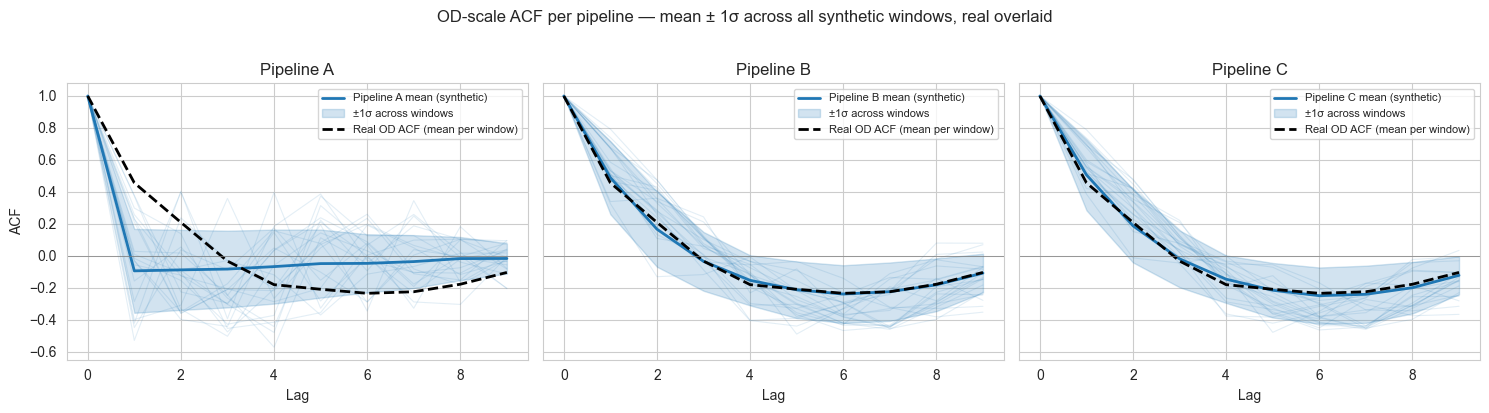

wrote revision/results/transform_ablation/figures/fig_acf_od.png
Real ACF lag-1=0.456, lag-5=-0.209


In [6]:
# fig_acf_od.png — 1x3 panels, OD-scale ACF mean ± 1σ band + real overlay + faint per-sample lines (Pitfall 3).
def aggregate_acf_per_pipeline_od(p: str, nlags: int = 9) -> dict:
    """Aggregate per-window ACF across all 5 seeds for pipeline p, on OD scale."""
    all_acfs = []
    for s in SEEDS:
        od = reconstruct_od(p, s)['od_samples']
        for w in od:
            all_acfs.append(compute_acf(w, nlags=nlags))
    arr = np.stack(all_acfs)
    return {'mean': arr.mean(axis=0), 'std': arr.std(axis=0),
            'samples': arr[np.random.default_rng(42).choice(arr.shape[0], 20, replace=False)]}

real_acf_per_window = np.stack([compute_acf(w, nlags=9) for w in real_windowed_OD])
real_acf_mean = real_acf_per_window.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for i, p in enumerate(PIPELINES):
    agg = aggregate_acf_per_pipeline_od(p)
    lags = np.arange(len(agg['mean']))
    # Faint per-sample ACFs (Pitfall 3 mitigation).
    for sample_acf in agg['samples']:
        axes[i].plot(lags, sample_acf, color='C0', alpha=0.12, lw=0.8)
    # Mean + ±1σ band
    axes[i].plot(lags, agg['mean'], color='C0', lw=2, label=f'Pipeline {p} mean (synthetic)')
    axes[i].fill_between(lags, agg['mean'] - agg['std'], agg['mean'] + agg['std'],
                          color='C0', alpha=0.2, label='±1σ across windows')
    # Real-data ACF overlay.
    axes[i].plot(lags, real_acf_mean, color='black', lw=2, linestyle='--', label='Real OD ACF (mean per window)')
    axes[i].set_title(f'Pipeline {p}')
    axes[i].set_xlabel('Lag')
    if i == 0:
        axes[i].set_ylabel('ACF')
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].axhline(0, color='gray', lw=0.5)
fig.suptitle('OD-scale ACF per pipeline — mean ± 1σ across all synthetic windows, real overlaid', y=1.02)
fig.tight_layout()
plt.savefig(FIG_DIR / 'fig_acf_od.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'wrote {FIG_DIR / "fig_acf_od.png"}')
print(f'Real ACF lag-1={real_acf_mean[1]:.3f}, lag-5={real_acf_mean[5]:.3f}')


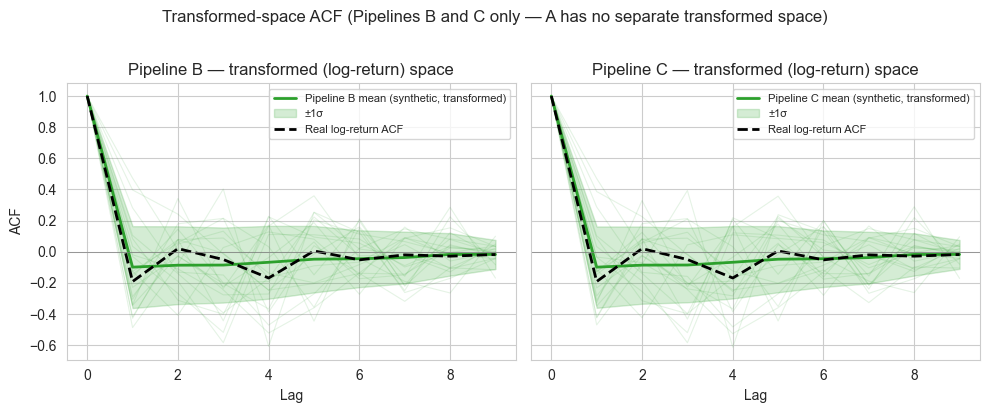

wrote revision/results/transform_ablation/figures/fig_acf_transformed.png


In [7]:
# fig_acf_transformed.png — 1x2 panels for B and C only (A has no separate transformed space).
def aggregate_acf_per_pipeline_transformed(p: str, nlags: int = 9) -> dict:
    all_acfs = []
    for s in SEEDS:
        r = reconstruct_od(p, s)
        trans = r['transformed']
        if trans is None:
            continue
        for w in trans:
            all_acfs.append(compute_acf(w, nlags=nlags))
    arr = np.stack(all_acfs)
    return {'mean': arr.mean(axis=0), 'std': arr.std(axis=0),
            'samples': arr[np.random.default_rng(43).choice(arr.shape[0], 20, replace=False)]}

# Real log-returns ACF (in standardized log-return space).
real_lr_acf = np.stack([compute_acf(w, nlags=9) for w in real_windowed_lr])
real_lr_acf_mean = real_lr_acf.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for i, p in enumerate(['B', 'C']):
    agg = aggregate_acf_per_pipeline_transformed(p)
    lags = np.arange(len(agg['mean']))
    for sample_acf in agg['samples']:
        axes[i].plot(lags, sample_acf, color='C2', alpha=0.12, lw=0.8)
    axes[i].plot(lags, agg['mean'], color='C2', lw=2, label=f'Pipeline {p} mean (synthetic, transformed)')
    axes[i].fill_between(lags, agg['mean'] - agg['std'], agg['mean'] + agg['std'],
                          color='C2', alpha=0.2, label='±1σ')
    axes[i].plot(lags, real_lr_acf_mean, color='black', lw=2, linestyle='--', label='Real log-return ACF')
    axes[i].set_title(f'Pipeline {p} — transformed (log-return) space')
    axes[i].set_xlabel('Lag')
    if i == 0:
        axes[i].set_ylabel('ACF')
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].axhline(0, color='gray', lw=0.5)
fig.suptitle('Transformed-space ACF (Pipelines B and C only — A has no separate transformed space)', y=1.02)
fig.tight_layout()
plt.savefig(FIG_DIR / 'fig_acf_transformed.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'wrote {FIG_DIR / "fig_acf_transformed.png"}')


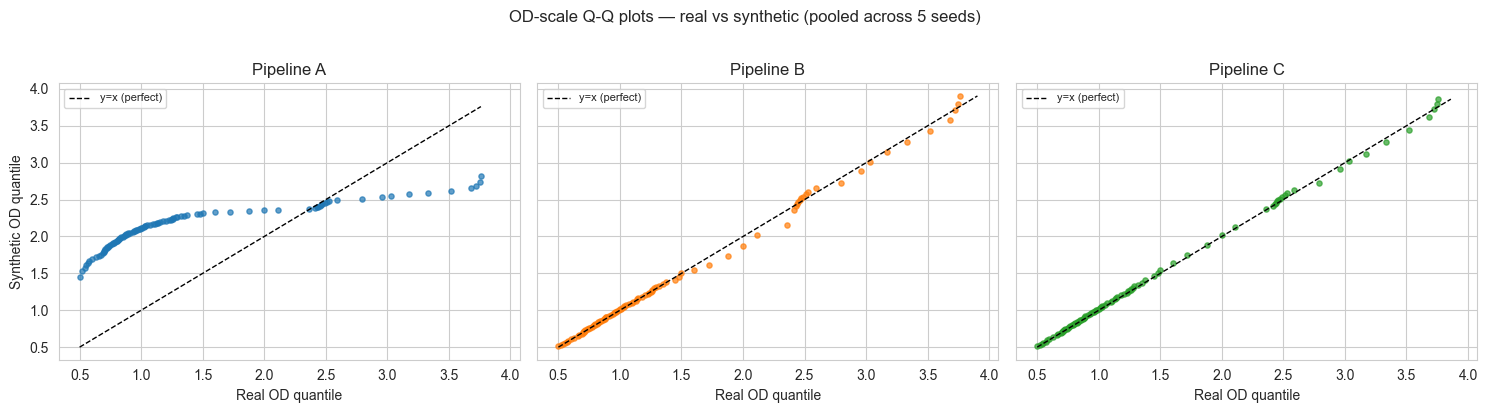

wrote revision/results/transform_ablation/figures/fig_qq_od.png


In [8]:
# fig_qq_od.png — 1x3 Q-Q panels, real OD vs pooled synthetic OD per pipeline.
qs = np.linspace(0.01, 0.99, 99)
real_quantiles = np.quantile(real_flat, qs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for i, p in enumerate(PIPELINES):
    pooled = np.concatenate([reconstruct_od(p, s)['od_samples'].reshape(-1) for s in SEEDS])
    synth_quantiles = np.quantile(pooled, qs)
    axes[i].scatter(real_quantiles, synth_quantiles, s=14, alpha=0.7, color=f'C{i}')
    lo = min(real_quantiles.min(), synth_quantiles.min())
    hi = max(real_quantiles.max(), synth_quantiles.max())
    axes[i].plot([lo, hi], [lo, hi], color='black', linestyle='--', lw=1, label='y=x (perfect)')
    axes[i].set_title(f'Pipeline {p}')
    axes[i].set_xlabel('Real OD quantile')
    if i == 0:
        axes[i].set_ylabel('Synthetic OD quantile')
    axes[i].legend(loc='upper left', fontsize=8)
fig.suptitle('OD-scale Q-Q plots — real vs synthetic (pooled across 5 seeds)', y=1.02)
fig.tight_layout()
plt.savefig(FIG_DIR / 'fig_qq_od.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'wrote {FIG_DIR / "fig_qq_od.png"}')


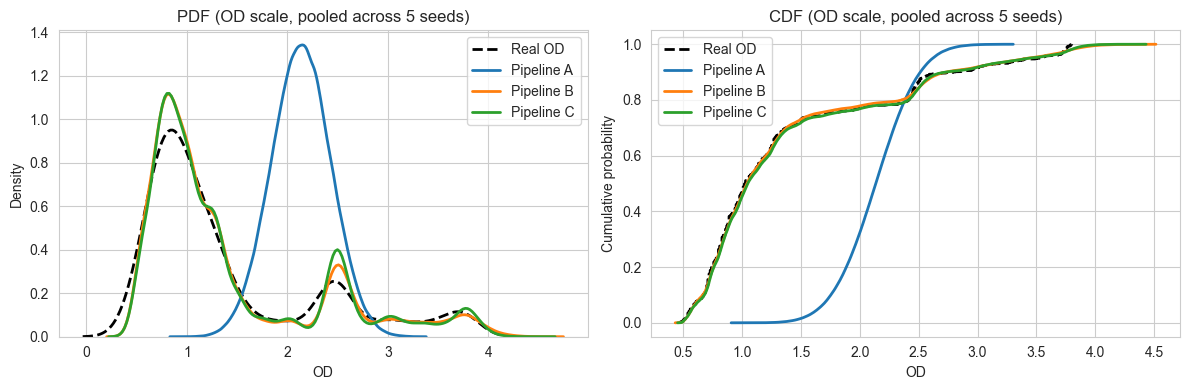

wrote revision/results/transform_ablation/figures/fig_pdf_od.png


In [9]:
# fig_pdf_od.png — 1x2 (PDF + CDF) overlay of real + 3 pipelines pooled across seeds.
pooled_by_pipeline = {p: np.concatenate([reconstruct_od(p, s)['od_samples'].reshape(-1) for s in SEEDS])
                       for p in PIPELINES}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# PDF panel
sns.kdeplot(real_flat, ax=axes[0], color='black', linestyle='--', lw=2, label='Real OD')
for i, p in enumerate(PIPELINES):
    sns.kdeplot(pooled_by_pipeline[p], ax=axes[0], color=f'C{i}', lw=2, label=f'Pipeline {p}')
axes[0].set_title('PDF (OD scale, pooled across 5 seeds)')
axes[0].set_xlabel('OD'); axes[0].set_ylabel('Density'); axes[0].legend()
# CDF panel — empirical CDF via sorted-rank.
def ecdf(x):
    xs = np.sort(x); ys = np.arange(1, len(xs) + 1) / len(xs)
    return xs, ys
xs_r, ys_r = ecdf(real_flat)
axes[1].plot(xs_r, ys_r, color='black', linestyle='--', lw=2, label='Real OD')
for i, p in enumerate(PIPELINES):
    xs_s, ys_s = ecdf(pooled_by_pipeline[p])
    axes[1].plot(xs_s, ys_s, color=f'C{i}', lw=2, label=f'Pipeline {p}')
axes[1].set_title('CDF (OD scale, pooled across 5 seeds)')
axes[1].set_xlabel('OD'); axes[1].set_ylabel('Cumulative probability'); axes[1].legend()
fig.tight_layout()
plt.savefig(FIG_DIR / 'fig_pdf_od.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'wrote {FIG_DIR / "fig_pdf_od.png"}')


  pipeline A: 1000 DTW values, mean=2.132


  pipeline B: 1000 DTW values, mean=0.199


  pipeline C: 1000 DTW values, mean=0.156


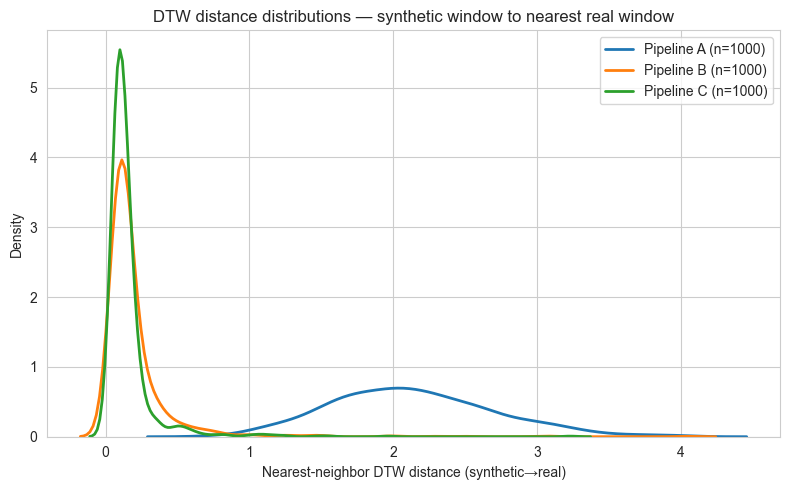

wrote revision/results/transform_ablation/figures/fig_dtw_distribution.png


In [10]:
# fig_dtw_distribution.png — KDE of nearest-neighbor DTW distances pooled across seeds per pipeline.
# Reuse the DTW values we already computed for metrics.csv (DTW_N_PAIRS per (p,s)).
# Recompute here so we have full per-window DTW vectors (metrics.csv stores only mean/std/median).
dtw_by_pipeline = {p: [] for p in PIPELINES}
for p in PIPELINES:
    for s in SEEDS:
        od = reconstruct_od(p, s)['od_samples']
        rng = np.random.default_rng(s * 31)
        n = min(DTW_N_PAIRS, od.shape[0])
        synth_idx = rng.choice(od.shape[0], size=n, replace=False)
        for i in synth_idx:
            best = min(compute_dtw(od[i], real_windowed_OD[j]) for j in range(real_windowed_OD.shape[0]))
            dtw_by_pipeline[p].append(best)
    print(f'  pipeline {p}: {len(dtw_by_pipeline[p])} DTW values, mean={np.mean(dtw_by_pipeline[p]):.3f}')

fig, ax = plt.subplots(figsize=(8, 5))
for i, p in enumerate(PIPELINES):
    sns.kdeplot(dtw_by_pipeline[p], ax=ax, color=f'C{i}', lw=2,
                label=f'Pipeline {p} (n={len(dtw_by_pipeline[p])})')
ax.set_xlabel('Nearest-neighbor DTW distance (synthetic→real)')
ax.set_ylabel('Density')
ax.set_title('DTW distance distributions — synthetic window to nearest real window')
ax.legend()
fig.tight_layout()
plt.savefig(FIG_DIR / 'fig_dtw_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'wrote {FIG_DIR / "fig_dtw_distribution.png"}')


## Task 2 — TSTR-lite sanity scaffolding (D-09.1-10, CD-4)

Per-pipeline 1-layer LSTM (32 hidden units) trained on synthetic OD windows, evaluated on
held-out real windows. Reports MSE + R² to `tstr_lite.json`. Averaged over 3 LSTM init
seeds (40, 41, 42) to capture initialization variance.

**Caveat (FLAG-E):** Synthetic train sets pool 5 seeds × 10× real ≈ 19,200 windows; the
real-only baseline trains on ~65 windows. The 295× train-budget asymmetry means a literal
R² gap should be read as a *lower bound* on synthetic utility, not a matched-budget
comparison. Phase 11 EVAL-01 owns the matched-budget headline TSTR result.

**Caveat (Pitfall 5):** Single architecture (1-layer LSTM, hidden=32). Different choices
could rank pipelines differently. This is sanity scaffolding, not the Phase 11 headline.

In [11]:
# TSTR-lite architecture (1-layer LSTM, 32 hidden units, sequence-length-9 → predict-1).
class TSTRLiteLSTM(torch.nn.Module):
    def __init__(self, hidden: int = 32):
        super().__init__()
        self.lstm = torch.nn.LSTM(input_size=1, hidden_size=hidden, num_layers=1, batch_first=True)
        self.fc = torch.nn.Linear(hidden, 1)

    def forward(self, x):  # x: (B, 9, 1) -> y: (B, 1)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


def r2_score_inline(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """R² inline (no sklearn dependency per RESEARCH Assumption A2)."""
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0


def train_eval_tstr(train_windows: np.ndarray, eval_windows: np.ndarray,
                     lstm_seed: int = 40, hidden: int = 32, epochs: int = 50,
                     bs: int = 64) -> dict:
    """Train a TSTR-lite LSTM on train_windows, evaluate next-step prediction MSE+R² on eval_windows."""
    torch.manual_seed(lstm_seed)
    rng = np.random.default_rng(lstm_seed)
    Xtr = torch.tensor(train_windows[:, :9], dtype=torch.float32).unsqueeze(-1)  # (N, 9, 1)
    ytr = torch.tensor(train_windows[:, 9:10], dtype=torch.float32)               # (N, 1)
    Xev = torch.tensor(eval_windows[:, :9], dtype=torch.float32).unsqueeze(-1)
    yev = torch.tensor(eval_windows[:, 9:10], dtype=torch.float32)
    model = TSTRLiteLSTM(hidden=hidden)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = torch.nn.MSELoss()
    n = Xtr.shape[0]
    for _ in range(epochs):
        idx = rng.permutation(n)
        for start in range(0, n, bs):
            j = idx[start:start + bs]
            xb, yb = Xtr[j], ytr[j]
            opt.zero_grad()
            yp = model(xb)
            loss = loss_fn(yp, yb)
            loss.backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        yev_pred = model(Xev).cpu().numpy()
    yev_np = yev.cpu().numpy()
    return {
        'mse': float(np.mean((yev_np - yev_pred) ** 2)),
        'r2': r2_score_inline(yev_np, yev_pred),
    }


In [12]:
# Run TSTR-lite per pipeline + real-only baseline.
# Per RESEARCH Q5: first 320 of 384(+) real windows = held-out eval; remainder = real-only train.
HELD_OUT_N = 320
real_eval = real_windowed_OD[:HELD_OUT_N]
real_train_for_baseline = real_windowed_OD[HELD_OUT_N:]  # (65, 10)

tstr = {}
INIT_SEEDS = (40, 41, 42)
for p in PIPELINES:
    synth_pool = np.concatenate([reconstruct_od(p, s)['od_samples'] for s in SEEDS], axis=0)
    per_init = {}
    for ls in INIT_SEEDS:
        per_init[int(ls)] = train_eval_tstr(synth_pool, real_eval, lstm_seed=ls)
    mses = [v['mse'] for v in per_init.values()]
    r2s = [v['r2']  for v in per_init.values()]
    tstr[p] = {
        'n_train_synth': int(synth_pool.shape[0]),
        'n_eval_real':   int(HELD_OUT_N),
        'mse_mean': float(np.mean(mses)), 'mse_std': float(np.std(mses)),
        'r2_mean':  float(np.mean(r2s)),  'r2_std':  float(np.std(r2s)),
        'per_init_seed': per_init,
    }
    print(f'  pipeline {p}: n_train={tstr[p]["n_train_synth"]}, '
          f'mse={tstr[p]["mse_mean"]:.4f}±{tstr[p]["mse_std"]:.4f}, '
          f'r2={tstr[p]["r2_mean"]:.3f}±{tstr[p]["r2_std"]:.3f}')

# Real-only baseline (trained on ~65 windows held out from synthetic eval set).
per_init_real = {int(ls): train_eval_tstr(real_train_for_baseline, real_eval, lstm_seed=ls)
                  for ls in INIT_SEEDS}
mses_r = [v['mse'] for v in per_init_real.values()]
r2s_r  = [v['r2']  for v in per_init_real.values()]
tstr['real_only_baseline'] = {
    'n_train_real': int(real_train_for_baseline.shape[0]),
    'n_eval_real':  int(HELD_OUT_N),
    'mse_mean': float(np.mean(mses_r)), 'mse_std': float(np.std(mses_r)),
    'r2_mean':  float(np.mean(r2s_r)),  'r2_std':  float(np.std(r2s_r)),
    'per_init_seed': per_init_real,
}
print(f'  real_only_baseline: n_train={tstr["real_only_baseline"]["n_train_real"]}, '
      f'mse={tstr["real_only_baseline"]["mse_mean"]:.4f}±{tstr["real_only_baseline"]["mse_std"]:.4f}, '
      f'r2={tstr["real_only_baseline"]["r2_mean"]:.3f}±{tstr["real_only_baseline"]["r2_std"]:.3f}')

# Append TSTR rows to metrics.csv.
extra_rows = []
for p, v in tstr.items():
    if p == 'real_only_baseline':
        continue
    extra_rows.append(dict(pipeline=p, seed=-1, metric_name='tstr_mse_mean', scale='OD', value=v['mse_mean']))
    extra_rows.append(dict(pipeline=p, seed=-1, metric_name='tstr_mse_std',  scale='OD', value=v['mse_std']))
    extra_rows.append(dict(pipeline=p, seed=-1, metric_name='tstr_r2_mean',  scale='OD', value=v['r2_mean']))
    extra_rows.append(dict(pipeline=p, seed=-1, metric_name='tstr_r2_std',   scale='OD', value=v['r2_std']))
df = pd.read_csv(OUT_ROOT / 'metrics.csv')
df = pd.concat([df, pd.DataFrame(extra_rows)], ignore_index=True)
df.to_csv(OUT_ROOT / 'metrics.csv', index=False)

# Write tstr_lite.json. Cast nested per_init_seed dict keys to strings for JSON compat.
def _to_jsonable(d):
    if isinstance(d, dict):
        return {str(k): _to_jsonable(v) for k, v in d.items()}
    if isinstance(d, (np.floating, np.integer)):
        return float(d)
    return d

(OUT_ROOT / 'tstr_lite.json').write_text(json.dumps(_to_jsonable(tstr), indent=2, default=float))
print('\nwrote tstr_lite.json')
print(json.dumps({k: {kk: vv for kk, vv in v.items() if kk != 'per_init_seed'}
                   for k, v in tstr.items()}, indent=2, default=float))


  pipeline A: n_train=19250, mse=1.4966±0.0509, r2=-5.346±0.216


  pipeline B: n_train=19200, mse=0.0005±0.0000, r2=0.998±0.000


  pipeline C: n_train=19200, mse=0.0005±0.0000, r2=0.998±0.000


  real_only_baseline: n_train=65, mse=3.3855±0.1376, r2=-13.354±0.583

wrote tstr_lite.json
{
  "A": {
    "n_train_synth": 19250,
    "n_eval_real": 320,
    "mse_mean": 1.4966133832931519,
    "mse_std": 0.05090917458958618,
    "r2_mean": -5.345507553213564,
    "r2_std": 0.21585023709679702
  },
  "B": {
    "n_train_synth": 19200,
    "n_eval_real": 320,
    "mse_mean": 0.000515717848126466,
    "mse_std": 2.4163283078105843e-05,
    "r2_mean": 0.9978134022336119,
    "r2_std": 0.0001024501382907885
  },
  "C": {
    "n_train_synth": 19200,
    "n_eval_real": 320,
    "mse_mean": 0.0005393064542052647,
    "mse_std": 3.541037431297257e-05,
    "r2_mean": 0.9977133885356433,
    "r2_std": 0.0001501368133112886
  },
  "real_only_baseline": {
    "n_train_real": 65,
    "n_eval_real": 320,
    "mse_mean": 3.385484536488851,
    "mse_std": 0.1375714345362611,
    "r2_mean": -13.354153352619454,
    "r2_std": 0.5832906516514351
  }
}
